In [4]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression  
from sklearn.preprocessing import PolynomialFeatures  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  

In [5]:
df = pd.read_csv("C:\\Users\\Liman\\Downloads\\50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [6]:
# Display dataset information
df_info = df.info()
df_description = df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [ ]:
salaires = pd.Series([2000, 2100, 2500, 2300, 2400, 3000, 10000])
Q1 = salaires.quantile(0.25)
Q3 = salaires.quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

outliers = salaires[(salaires < borne_basse) | (salaires > borne_haute)]
print("Outliers :", outliers.values)

Outliers : [10000]


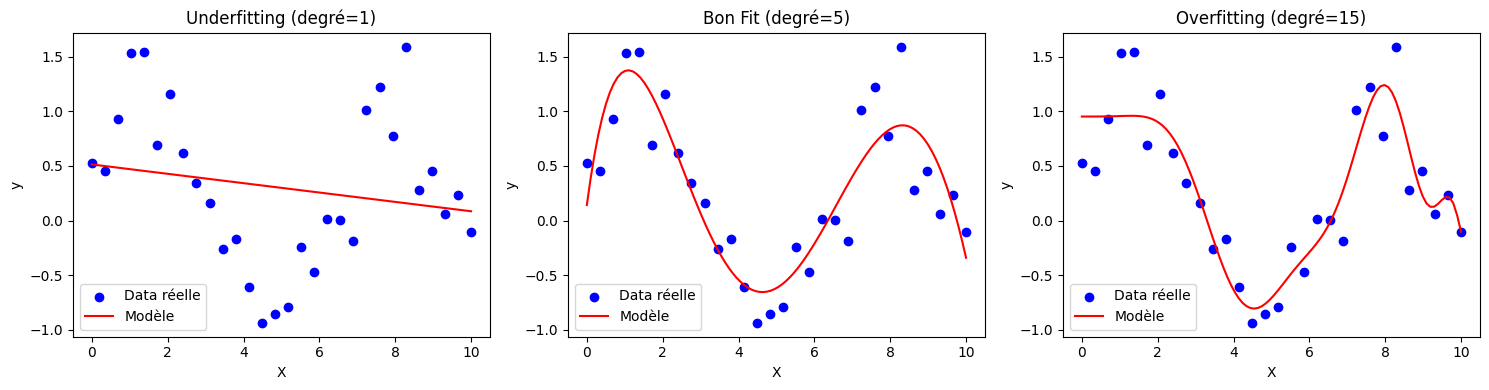

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1️⃣ Générer des données non linéaires
np.random.seed(0)
X = np.linspace(0, 10, 30).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.randn(30) * 0.3  # sinus + bruit

# Fonction pour entraîner et tracer le modèle
def plot_model(degree, title, pos):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    X_fit = np.linspace(0, 10, 100).reshape(-1, 1)
    y_fit = model.predict(poly.transform(X_fit))

    plt.subplot(1, 3, pos)
    plt.scatter(X, y, color='blue', label='Data réelle')
    plt.plot(X_fit, y_fit, color='red', label='Modèle')
    plt.title(title)
    plt.legend()
    plt.xlabel("X")
    plt.ylabel("y")

# 2️⃣ Tracer les trois cas
plt.figure(figsize=(15, 4))
plot_model(1, "Underfitting (degré=1)", 1)
plot_model(5, "Bon Fit (degré=5)", 2)
plot_model(15, "Overfitting (degré=15)", 3)
plt.tight_layout()
plt.show()


In [26]:
x = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0,
              4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0,
              9.5, 10.3, 10.5])

y = np.array([39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 
              64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938,
              66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812,
              109431, 105582, 116969])

x = x.reshape(-1, 1)

x_train , y_train ,x_test ,y_test = train_test_split(x,y,test_size=0.3, random_state=42)
model= LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = model.predict(x)
y_pred

array([ 36856.67883127,  38513.9318162 ,  40171.18480112,  44314.31726342,
        45971.57024834,  51771.95569556,  52600.58218802,  54257.83517294,
        54257.83517294,  58400.96763524,  60058.22062016,  60886.84711262,
        65029.97957493,  68344.48554477,  70001.73852969,  71658.99151461,
        76630.75046937,  77459.37696183,  84088.38890151,  86574.2683789 ,
        93203.28031858,  95689.15979596,  99832.29225826, 102318.17173564,
       106461.30419794, 113090.31613763, 114747.56912255])

In [28]:
defirence = y - y_pred
defirence

array([  2486.32116873,   7691.0681838 ,  -2440.18480112,   -789.31726342,
        -6080.57024834,   4870.04430444,   7549.41781198,    187.16482706,
        10187.16482706,  -1211.96763524,   3159.77937984,  -5092.84711262,
        -8072.97957493, -11263.48554477,  -8890.73852969,  -3720.99151461,
       -10601.75046937,   5628.62303817,  -2725.38890151,   7365.7316211 ,
        -1465.28031858,   2583.84020404,   1469.70774174,  11493.82826436,
         2969.69580206,  -7508.31613763,   2221.43087745])

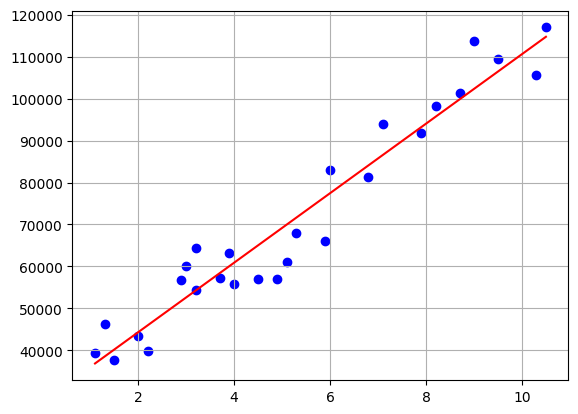

In [29]:
plt.scatter(x,y , color = 'blue')
plt.plot(x , y_pred , color ='red')
plt.grid()
plt.show()

Équation de la droite : y = 2.50x + 60.00
Prédiction pour 7 heures d'étude : 77.50


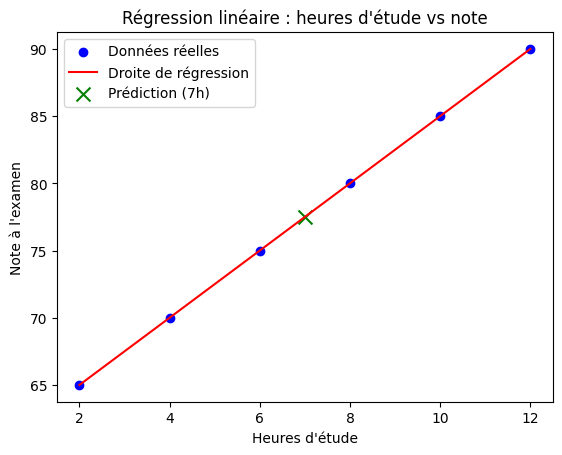

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Données
X = np.array([2, 4, 6, 8, 10, 12]).reshape(-1, 1)  # variable indépendante
y = np.array([65, 70, 75, 80, 85, 90])             # variable dépendante

# Modèle de régression linéaire
model = LinearRegression()
model.fit(X, y)

# Coefficients
a = model.coef_[0]   # pente
b = model.intercept_ # intercept

print(f"Équation de la droite : y = {a:.2f}x + {b:.2f}")

# Prédiction pour 7 heures
prediction = model.predict([[7]])
print(f"Prédiction pour 7 heures d'étude : {prediction[0]:.2f}")

# Visualisation
plt.scatter(X, y, color="blue", label="Données réelles")
plt.plot(X, model.predict(X), color="red", label="Droite de régression")
plt.scatter(7, prediction, color="green", marker="x", s=100, label="Prédiction (7h)")
plt.xlabel("Heures d'étude")
plt.ylabel("Note à l'examen")
plt.title("Régression linéaire : heures d'étude vs note")
plt.legend()
plt.show()


In [33]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from sklearn.linear_model import LinearRegression  

In [34]:
house_features = np.array([
    [50, 2, 10],  
    [75, 3, 5],  
    [100, 3, 8],  
    [125, 4, 4],  
    [150, 4, 2]
])
# Define the dependent variable (House Price in $)
house_prices = np.array([150000, 200000, 250000, 300000, 350000])

In [35]:
model = LinearRegression()
# Train the model using the dataset
model.fit(house_features, house_prices)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
# Get coefficients and intercept
m_values = model.coef_  # Slopes
b = model.intercept_  # Intercept
# Display the equation
print(f"Equation of the regression line: Y = {m_values[0]:.2f}X1 + {m_values[1]:.2f}X2 + {m_values[2]:.2f}X3 + {b:.2f}")

Equation of the regression line: Y = 2000.00X1 + -0.00X2 + -0.00X3 + 50000.00


In [ ]:
# New house data for prediction (Size, Bedrooms, Age)
new_house = np.array([[120, 3, 6]])
# Predict the price
predicted_price = model.predict(new_house)
# Display prediction
print(f"Predicted House Price: ${predicted_price[0]:.2f}")

array([290000.])

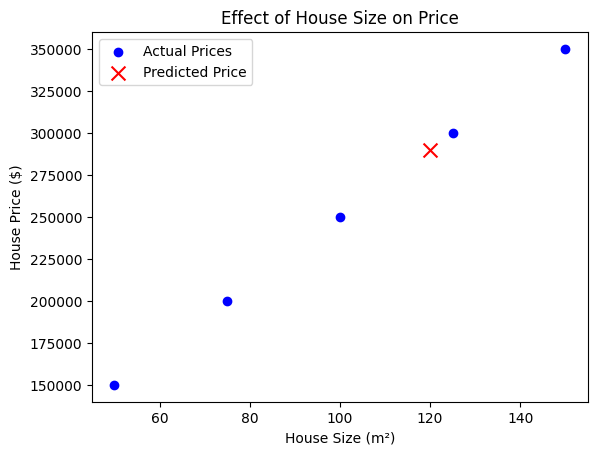

In [39]:
plt.scatter(house_features[:, 0], house_prices, color='blue', label='Actual Prices')  # Actual prices
plt.scatter(new_house[:, 0], predicted_price, color='red', label='Predicted Price', marker='x', s=100)  # Predicted price
plt.xlabel("House Size (m²)")
plt.ylabel("House Price ($)")
plt.title("Effect of House Size on Price")
plt.legend()
plt.show()

In [40]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
Y = np.array([2, 6, 14, 28, 50, 80, 120, 170, 230, 310]) 

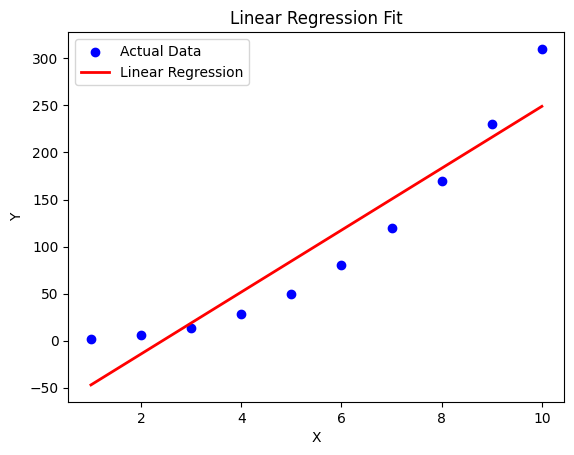

In [41]:
linear_model = LinearRegression()
linear_model.fit(X, Y)
# Predict using Linear Regression
Y_pred_linear = linear_model.predict(X)
# Plot results
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred_linear, color='red', linewidth=2, label='Linear Regression')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [42]:
# Transform the input to include polynomial features (degree=2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
# Train a Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_poly, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


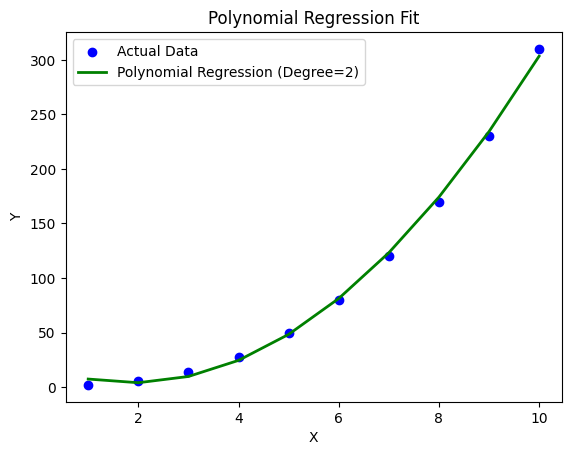

In [43]:
Y_pred_poly = poly_model.predict(X_poly)
# Plot results
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred_poly, color='green', linewidth=2, label='Polynomial Regression (Degree=2)')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate a non-linear dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
Y = np.array([2, 6, 14, 28, 50, 80, 120, 170, 230, 310])  

# First split: Training (60%) and Temporary Set (40%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)

# Second split: Validation (20%) and Test (20%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Print dataset sizes
print("Training Set Size:", len(X_train))
print("Validation Set Size:", len(X_val))
print("Test Set Size:", len(X_test))

Training Set Size: 6
Validation Set Size: 2
Test Set Size: 2


In [45]:
from sklearn.metrics import mean_absolute_error
# Example data
Y_actual = [100, 200, 300, 400, 500]
Y_predicted = [110, 190, 290, 410, 490]
# Compute MAE
mae = mean_absolute_error(Y_actual, Y_predicted)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 10.0


In [46]:
from sklearn.metrics import mean_squared_error
Y_actual = [100, 200, 300, 400, 500]
Y_prédit = [110, 190, 290, 410, 490]
# Compute MSE
mse = mean_squared_error(Y_actual, Y_predicted)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 100.0


In [47]:
# Compute RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 10.0


In [48]:
from sklearn.metrics import r2_score
Y_actual = [100, 200, 300, 400, 500]
Y_predicted = [110, 190, 290, 410, 490]
# Compute R² score
r2 = r2_score(Y_actual, Y_predicted)
print("R-Squared (R²):", r2)

R-Squared (R²): 0.995


In [ ]:
‪C:\Users\Liman\Downloads\50_Startups (1).csv

In [49]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression  
from sklearn.preprocessing import PolynomialFeatures  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  

In [50]:
df = pd.read_csv("C:\\Users\\Liman\\Downloads\\50_Startups (1).csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
# Display dataset information
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [53]:
df_description = df.describe()
df_description

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [54]:
df = pd.get_dummies(df, columns=['State'], drop_first=True)

In [56]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [57]:
X = df[['R&D Spend']]  
y = df['Profit'] 

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = model.predict(X_test)

In [63]:
mae = mean_absolute_error(y_test, y_pred)  
mse = mean_squared_error(y_test, y_pred)  
rmse = np.sqrt(mse)  
r2 = r2_score(y_test, y_pred)  

print(f"MAE: {mae:.2f}")  
print(f"MSE: {mse:.2f}")  
print(f"RMSE: {rmse:.2f}")  
print(f"R2 Score: {r2:.2f}")

MAE: 6077.36
MSE: 59510962.81
RMSE: 7714.33
R2 Score: 0.93


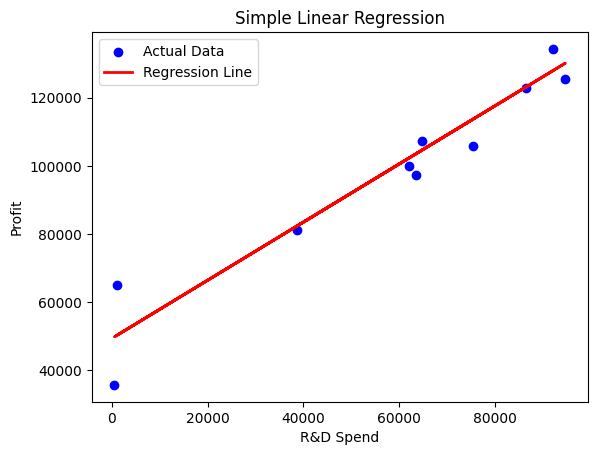

In [64]:
plt.scatter(X_test, y_test, color='blue', label='Actual Data')  
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')  
plt.xlabel("R&D Spend")  
plt.ylabel("Profit")  
plt.title("Simple Linear Regression")  
plt.legend()  
plt.show()

In [65]:
# Multiple Linear Regression (Using R&D Spend, Administration, and Marketing Spend)
X_multi = df[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida']]
y_multi = df['Profit']

In [66]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Initializing a Linear Regression model
model_multi = LinearRegression()

# Training the model using the training dataset
model_multi.fit(X_train_m, y_train_m)

# Making predictions on the test dataset
y_pred_multi = model_multi.predict(X_test_m)

# Calculating evaluation metrics
mae_multi = mean_absolute_error(y_test_m, y_pred_multi)  # Mean Absolute Error
mse_multi = mean_squared_error(y_test_m, y_pred_multi)  # Mean Squared Error
rmse_multi = np.sqrt(mse_multi)  # Root Mean Squared Error
r2_multi = r2_score(y_test_m, y_pred_multi)  # R-squared score (coefficient of determination)

In [67]:
# Polynomial Regression (Model a non-linear relationship with R&D Spend)
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(df[['R&D Spend']])

In [68]:
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)

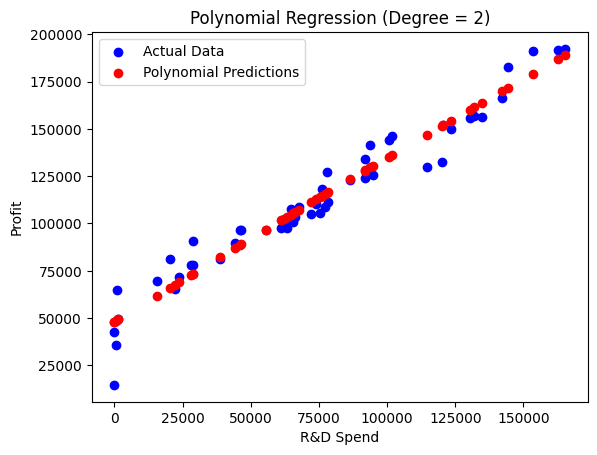

In [69]:
plt.scatter(df['R&D Spend'], y, color='blue', label='Actual Data')  
plt.scatter(df['R&D Spend'], y_pred_poly, color='red', label='Polynomial Predictions')  
plt.xlabel("R&D Spend")  
plt.ylabel("Profit")  
plt.title("Polynomial Regression (Degree = 2)")  
plt.legend()  
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

In [71]:
# Example dataset (house size vs price)
X = np.array([[500], [600], [700], [800], [900], [1000], [1100], [1200]])
Y = np.array([150000, 180000, 210000, 240000, 270000, 300000, 330000, 360000])

In [72]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [73]:
ridge_model = Ridge(alpha=1.0)  # λ = 1.0 (Regularization strength)
ridge_model.fit(X_train, Y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [74]:
Y_pred = ridge_model.predict(X_test)
print("Predicted Prices:", Y_pred)

Predicted Prices: [180000.23999928 299999.88000036]


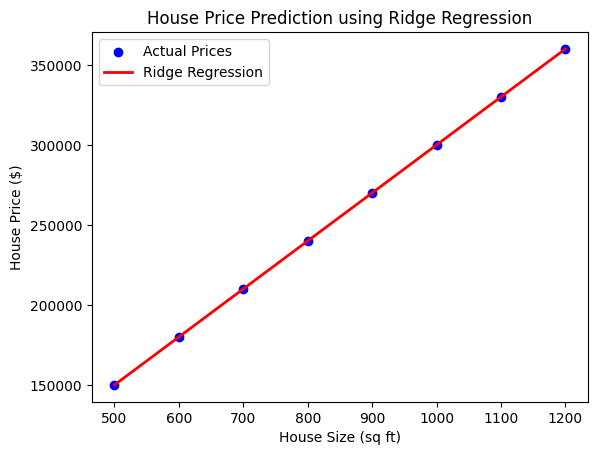

In [76]:
plt.scatter(X, Y, color='blue', label='Actual Prices')
plt.plot(X, ridge_model.predict(X), color='red', linewidth=2, label='Ridge Regression')
plt.xlabel("House Size (sq ft)")
plt.ylabel("House Price ($)")
plt.title("House Price Prediction using Ridge Regression")
plt.legend()
plt.show()

In [77]:
from sklearn.linear_model import LinearRegression
# Train a simple Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)
# Compare coefficients
print("Linear Regression Coefficients:", linear_model.coef_)
print("Ridge Regression Coefficients:", ridge_model.coef_)

Linear Regression Coefficients: [300.]
Ridge Regression Coefficients: [299.9991]
